# Day 2 — DBSCAN and Hierarchical Clustering

**Dataset used:** Iris Dataset (`Iris.csv`)

---

### Today's Learning Objectives
- Explain the limitations of the K-Means algorithm and when to prefer another algorithm.
- Apply DBSCAN and interpret the results (clusters and noise/outlier points).
- Build and read a dendrogram for hierarchical clustering, and choose the right method for each situation.

### Core Topics
1. Limitations of K-Means
2. DBSCAN: density-based clustering and noise detection
3. DBSCAN parameters: `eps` and `min_samples`
4. Hierarchical clustering and dendrograms
5. Choosing the appropriate clustering method
6. Hands-on lab: comparing clustering methods


We import the libraries we'll need throughout the notebook:
- `pandas` and `numpy` for data handling.
- `matplotlib` for plotting.
- `sklearn` for the K-Means and DBSCAN algorithms, `StandardScaler`, and `silhouette_score`.
- `scipy.cluster.hierarchy` for building the dendrogram and the `linkage` algorithm.

We'll also set `random_state=42` everywhere randomness is involved, to ensure the results are reproducible every time the notebook is run.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
print("All libraries imported successfully.")


All libraries imported successfully.


## Recap — Quick Retrieval of Day 1 Dataset

Today's lab requires running DBSCAN and hierarchical clustering on **the same Day 1 dataset**, so the comparison across all three methods (K-Means, DBSCAN, and hierarchical clustering) is fair and based on the same scaled data.

So we'll briefly repeat the Day 1 steps here:
1. Load the Iris dataset.
2. Keep only the numeric columns (we exclude `Id` and `Species` since unsupervised clustering doesn't use labels).
3. Scale the data using `StandardScaler` — **key rule:** data should always be scaled before clustering, since both K-Means and DBSCAN rely on Euclidean distance, and any column with a large value range would dominate columns with a smaller range.
4. Run K-Means with `k=3` (the value known from Day 1 via the Elbow Method and silhouette score, which also matches the fact that Iris has 3 true classes) to get `labels_kmeans`, which we'll use later for comparison.


In [3]:
df = pd.read_csv("Iris.csv")
print(df.shape)
df.head()


(150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X_raw = df[feature_cols].values

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Mean of each column after scaling (should be close to 0):", np.round(X.mean(axis=0), 3))
print("Standard deviation of each column after scaling (should be close to 1):", np.round(X.std(axis=0), 3))


Mean of each column after scaling (should be close to 0): [-0. -0.  0. -0.]
Standard deviation of each column after scaling (should be close to 1): [1. 1. 1. 1.]


In [5]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans.fit_predict(X)

sil_kmeans = silhouette_score(X, labels_kmeans)
print("Number of points per cluster (K-Means):", np.bincount(labels_kmeans))
print(f"Silhouette Score for K-Means: {sil_kmeans:.3f}")


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Number of points per cluster (K-Means): [53 50 47]
Silhouette Score for K-Means: 0.459


## 2.1 Why K-Means Isn't Always Enough

The K-Means algorithm is powerful and fast, but it has real limitations we should be aware of:

| Limitation | Impact |
|---|---|
| The number of clusters `k` must be specified in advance | If we don't know the true number of groups, we need to try several values (elbow / silhouette) |
| Assumes clusters are spherical and similar in size | Fails with irregularly shaped data or varying densities |
| Forces every point to belong to a cluster | Even clear outliers are forcibly merged into the nearest cluster, distorting the result |

This third limitation in particular is what **DBSCAN** and **hierarchical clustering** address — the topic of Day 2.


## 2.2 DBSCAN — Density-Based Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups points that are densely packed together, and labels points in sparse regions as **noise / outliers**.

### The two key advantages of DBSCAN over K-Means:
1. **Automatically detects the number of clusters** — no need to specify `k` in advance.
2. **Can detect irregularly shaped clusters**, explicitly flagging outliers instead of forcing them into a cluster.

### The two key parameters:

| Parameter | What it controls |
|---|---|
| `eps` | The maximum distance between two points for them to be considered "neighbors" |
| `min_samples` | The minimum number of neighbors required to form a dense region (cluster) |

Points labeled `-1` are **noise / outlier** points, not an actual cluster.

### Practical step: choosing `eps` systematically (k-distance plot)
Instead of guessing `eps` randomly, we use a common approach: compute the distance from each point to its `min_samples`-th nearest neighbor, then sort and plot these distances — the point where an "elbow" appears in the plot gives us a good estimate for an appropriate `eps` value.


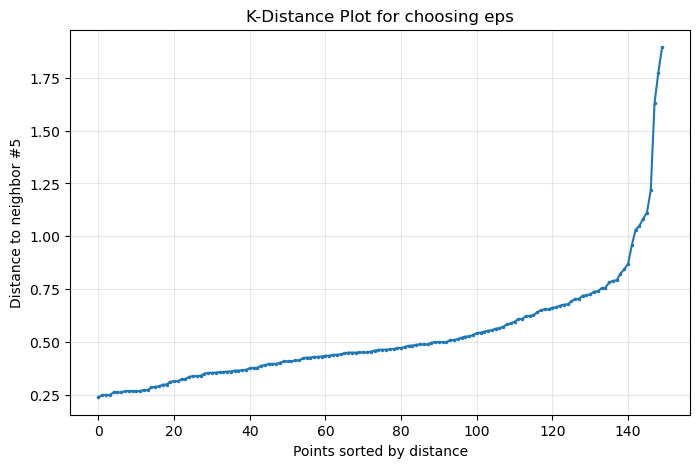

In [6]:
from sklearn.neighbors import NearestNeighbors

min_samples_choice = 5  

neighbors = NearestNeighbors(n_neighbors=min_samples_choice)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

k_distances = np.sort(distances[:, -1])

plt.plot(k_distances, marker=".", markersize=3)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to neighbor #{min_samples_choice}")
plt.title("K-Distance Plot for choosing eps")
plt.grid(alpha=0.3)
plt.show()


**Interpretation note:** The sharp rise (the "elbow") in the plot above indicates a suitable value for `eps` — points before the elbow are dense (close to their neighbors), while points after it are more scattered (candidates for noise). For the scaled Iris data, a value around `eps ≈ 0.6 - 0.8` often gives a reasonable result — we'll try several values and compare.


In [7]:
eps_candidates = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

print(f"{'eps':>6} | {'n_clusters':>14} | {'n_noise':>12} | {'Silhouette (no noise)':>25}")
print("-" * 70)
for eps_val in eps_candidates:
    db_trial = DBSCAN(eps=eps_val, min_samples=min_samples_choice)
    labels_trial = db_trial.fit_predict(X)
    n_clusters = len(set(labels_trial)) - (1 if -1 in labels_trial else 0)
    n_noise = int(np.sum(labels_trial == -1))

    if n_clusters >= 2:
        mask = labels_trial != -1
        sil = silhouette_score(X[mask], labels_trial[mask])
        sil_str = f"{sil:.3f}"
    else:
        sil_str = "N/A"

    print(f"{eps_val:>6} | {n_clusters:>14} | {n_noise:>12} | {sil_str:>25}")


   eps |     n_clusters |      n_noise |     Silhouette (no noise)
----------------------------------------------------------------------
   0.4 |              6 |           66 |                     0.485
   0.5 |              2 |           35 |                     0.653
   0.6 |              2 |           26 |                     0.641
   0.7 |              2 |            8 |                     0.610
   0.8 |              2 |            4 |                     0.596
   0.9 |              2 |            4 |                     0.596
   1.0 |              2 |            3 |                     0.594


### Lab Step 1: Run DBSCAN on the Day 1 dataset and report the result

Based on the table above, we choose the value that gives a reasonable number of clusters (close to the true structure of the data) with a not-excessive amount of noise. We'll fix `eps=0.6` and `min_samples=5` as the final setting, and report the result formally.


In [8]:
EPS_FINAL = 0.6
MIN_SAMPLES_FINAL = 5

dbscan = DBSCAN(eps=EPS_FINAL, min_samples=MIN_SAMPLES_FINAL)
labels_dbscan = dbscan.fit_predict(X)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_dbscan = int(np.sum(labels_dbscan == -1))

print("===== DBSCAN Result =====")
print(f"eps = {EPS_FINAL}, min_samples = {MIN_SAMPLES_FINAL}")
print(f"Number of clusters found: {n_clusters_dbscan}")
print(f"Number of noise points (outliers): {n_noise_dbscan} out of {len(X)} points")
print(f"Noise ratio: {n_noise_dbscan / len(X):.1%}")
print("Point distribution per label:", dict(zip(*np.unique(labels_dbscan, return_counts=True))))


===== DBSCAN Result =====
eps = 0.6, min_samples = 5
Number of clusters found: 2
Number of noise points (outliers): 26 out of 150 points
Noise ratio: 17.3%
Point distribution per label: {np.int64(-1): np.int64(26), np.int64(0): np.int64(46), np.int64(1): np.int64(78)}


In [ ]:
# Visualizing the DBSCAN clusters (using the first two scaled petal columns for simplicity)
plt.figure(figsize=(8, 6))
unique_labels = set(labels_dbscan)
colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 3)))

for label, color in zip(unique_labels, colors):
    mask = labels_dbscan == label
    if label == -1:
        plt.scatter(X[mask, 2], X[mask, 3], c="black", marker="x", s=60, label="Noise")
    else:
        plt.scatter(X[mask, 2], X[mask, 3], color=color, s=50, label=f"Cluster {label}")

plt.xlabel("PetalLengthCm (scaled)")
plt.ylabel("PetalWidthCm (scaled)")
plt.title(f"DBSCAN Results (eps={EPS_FINAL}, min_samples={MIN_SAMPLES_FINAL})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 2.3 Hierarchical Clustering

Hierarchical clustering builds a **tree of clusters**: it starts with every point as its own cluster, then iteratively merges the two closest clusters, until all points are merged into a single cluster.

The result is displayed as a **dendrogram** — a tree diagram that can be "cut" at any height to obtain any number of clusters. This approach doesn't need `k` specified in advance, and it fully reveals the nested structure of the data.

We use a linkage method — we'll go with `ward`, the most common method, since it minimizes within-cluster variance at every merge step.


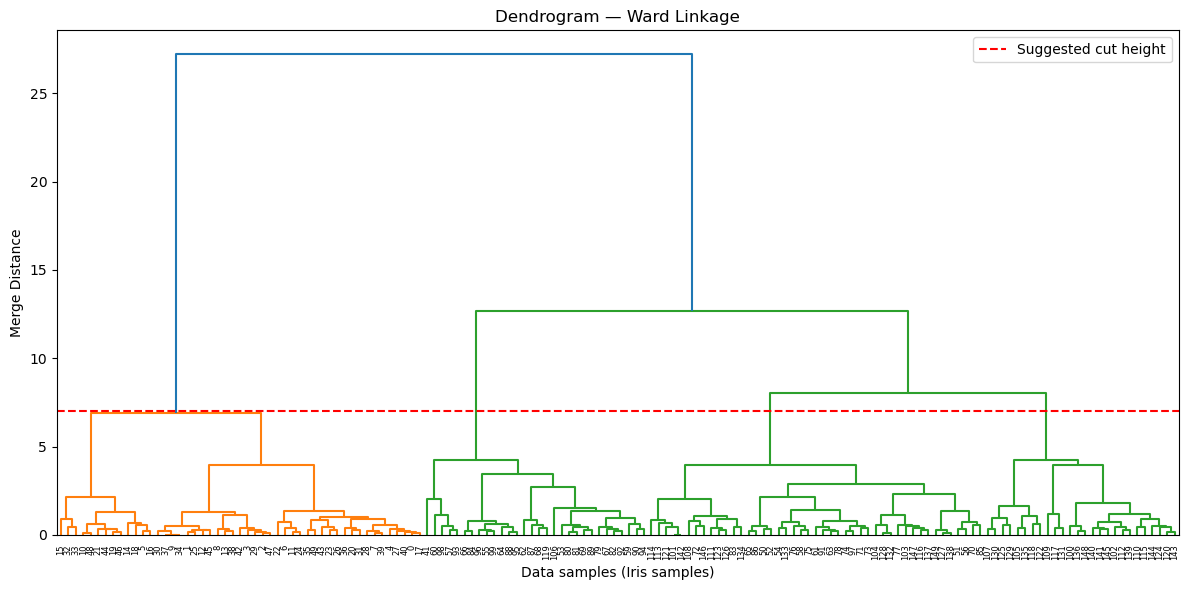

In [9]:
Z = linkage(X, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode=None, leaf_rotation=90, leaf_font_size=6)
plt.title("Dendrogram — Ward Linkage")
plt.xlabel("Data samples (Iris samples)")
plt.ylabel("Merge Distance")
plt.axhline(y=7, color="red", linestyle="--", label="Suggested cut height")
plt.legend()
plt.tight_layout()
plt.show()


### Lab Step 2: Choosing the Cut Height and the Resulting Number of Clusters

Looking at the dendrogram above, we notice that the largest vertical "jump" without any merge occurs around height **7** (the dashed red line). Cutting at this height naturally splits the data into a small number of clear clusters, following the same logic used in the elbow method for K-Means.

We use the `fcluster` function to actually cut the tree at this height and get the cluster labels.


In [10]:
CUT_HEIGHT = 7

labels_hierarchical = fcluster(Z, t=CUT_HEIGHT, criterion="distance")
n_clusters_hier = len(set(labels_hierarchical))

print(f"Chosen cut height: {CUT_HEIGHT}")
print(f"Resulting number of clusters: {n_clusters_hier}")
print("Point distribution per cluster:", dict(zip(*np.unique(labels_hierarchical, return_counts=True))))

sil_hier = silhouette_score(X, labels_hierarchical)
print(f"Silhouette Score for hierarchical clustering: {sil_hier:.3f}")


Chosen cut height: 7
Resulting number of clusters: 4
Point distribution per cluster: {np.int32(1): np.int64(49), np.int32(2): np.int64(30), np.int32(3): np.int64(45), np.int32(4): np.int64(26)}
Silhouette Score for hierarchical clustering: 0.399


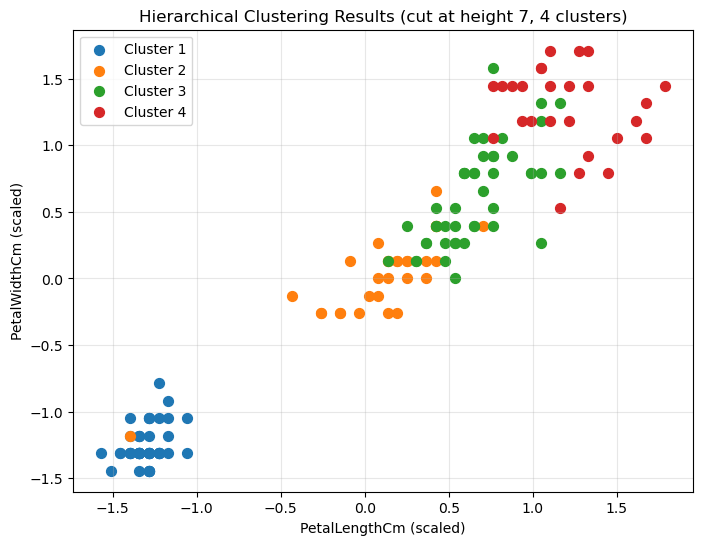

In [11]:
plt.figure(figsize=(8, 6))
for label in np.unique(labels_hierarchical):
    mask = labels_hierarchical == label
    plt.scatter(X[mask, 2], X[mask, 3], s=50, label=f"Cluster {label}")

plt.xlabel("PetalLengthCm (scaled)")
plt.ylabel("PetalWidthCm (scaled)")
plt.title(f"Hierarchical Clustering Results (cut at height {CUT_HEIGHT}, {n_clusters_hier} clusters)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 2.4 Choosing the Right Method

| Method | Best when | Watch out for |
|---|---|---|
| **K-Means** | Clusters are spherical and similar in size, and `k` is roughly known | Forces outliers into a cluster; requires specifying `k` |
| **DBSCAN** | Irregular shapes, and presence of noise/outliers | Very sensitive to `eps`; struggles with varying densities |
| **Hierarchical** | When we want a nested structure or a dendrogram | Slow on very large datasets |


## Hands-on Lab: Comparing the Three Clustering Methods

### Step 3: Compare the results of K-Means, DBSCAN, and hierarchical clustering on the same data

We compare the three methods from three angles:
1. **Quantitative summary table** (number of clusters, number of noise points, silhouette score).
2. **Side-by-side visual comparison** on the same axes.
3. **Level of agreement between the methods** using the Adjusted Rand Index (ARI), also compared against the true labels (`Species`) as a reference (note that these true labels are not used during the clustering itself, only for final evaluation).


In [12]:
def summarize(name, labels, X):
    labels = np.array(labels)
    unique = set(labels)
    n_noise = int(np.sum(labels == -1)) if -1 in unique else 0
    n_clusters = len(unique) - (1 if -1 in unique else 0)

    if -1 in unique:
        mask = labels != -1
        sil = silhouette_score(X[mask], labels[mask]) if n_clusters >= 2 else np.nan
    else:
        sil = silhouette_score(X, labels) if n_clusters >= 2 else np.nan

    return {
        "Method": name,
        "Num Clusters": n_clusters,
        "Noise Points": n_noise,
        "Silhouette Score": round(sil, 3) if not np.isnan(sil) else "—",
    }

summary_df = pd.DataFrame([
    summarize("K-Means (k=3)", labels_kmeans, X),
    summarize(f"DBSCAN (eps={EPS_FINAL})", labels_dbscan, X),
    summarize(f"Hierarchical (cut={CUT_HEIGHT})", labels_hierarchical, X),
])
summary_df


,Method,Num Clusters,Noise Points,Silhouette Score
0,K-Means (k=3),3,0,0.459
1,DBSCAN (eps=0.6),2,26,0.641
2,Hierarchical (cut=7),4,0,0.399


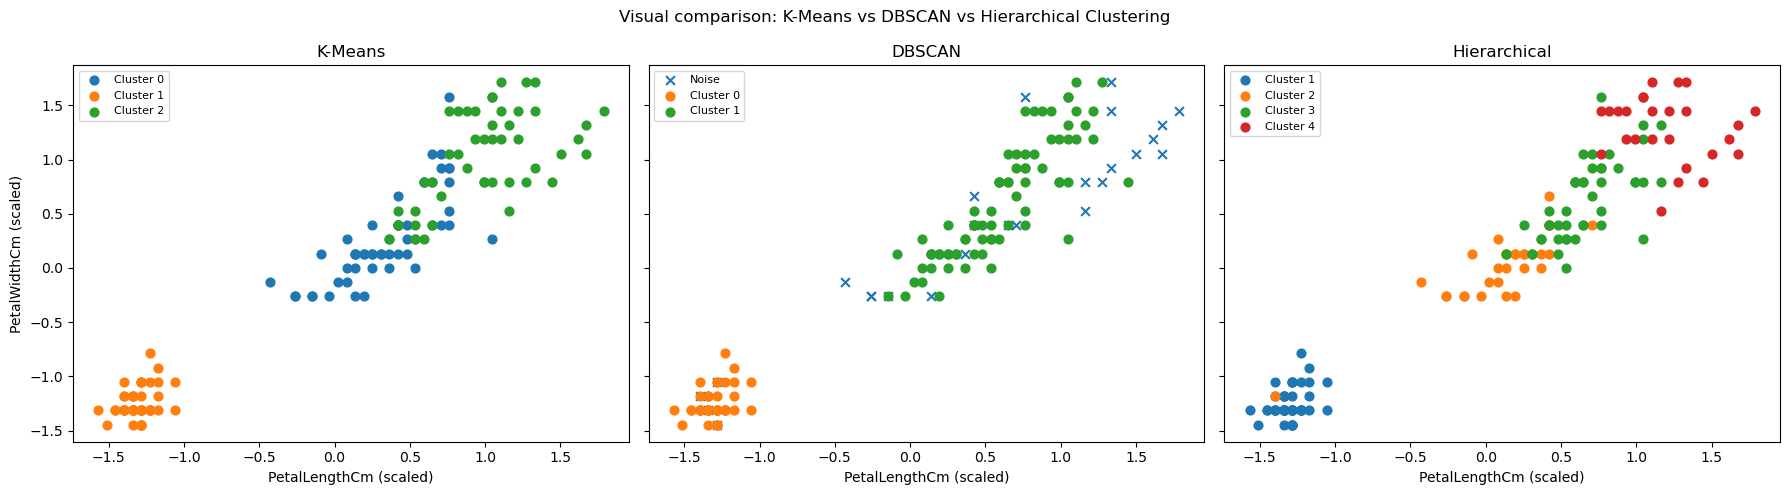

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

methods = [
    ("K-Means", labels_kmeans),
    ("DBSCAN", labels_dbscan),
    ("Hierarchical", labels_hierarchical),
]

for ax, (name, labels) in zip(axes, methods):
    labels = np.array(labels)
    for label in np.unique(labels):
        mask = labels == label
        marker = "x" if label == -1 else "o"
        clabel = "Noise" if label == -1 else f"Cluster {label}"
        ax.scatter(X[mask, 2], X[mask, 3], marker=marker, s=40, label=clabel)
    ax.set_title(name)
    ax.set_xlabel("PetalLengthCm (scaled)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("PetalWidthCm (scaled)")
plt.suptitle("Visual comparison: K-Means vs DBSCAN vs Hierarchical Clustering")
plt.tight_layout()
plt.show()


In [14]:
species_true = df["Species"].astype("category").cat.codes.values

ari_table = pd.DataFrame({
    "Comparison": [
        "K-Means vs True Labels",
        "DBSCAN vs True Labels",
        "Hierarchical vs True Labels",
        "K-Means vs DBSCAN",
        "K-Means vs Hierarchical",
    ],
    "Adjusted Rand Index (ARI)": [
        round(adjusted_rand_score(species_true, labels_kmeans), 3),
        round(adjusted_rand_score(species_true, labels_dbscan), 3),
        round(adjusted_rand_score(species_true, labels_hierarchical), 3),
        round(adjusted_rand_score(labels_kmeans, labels_dbscan), 3),
        round(adjusted_rand_score(labels_kmeans, labels_hierarchical), 3),
    ],
})
ari_table


,Comparison,Adjusted Rand Index (ARI)
0,K-Means vs True Labels,0.620
1,DBSCAN vs True Labels,0.471
2,Hierarchical vs True Labels,0.588
3,K-Means vs DBSCAN,0.466
4,K-Means vs Hierarchical,0.610


**Interpreting the ARI metric:** A value close to `1.0` means near-perfect agreement between two clusterings, while a value close to `0` means no better agreement than random chance. Our use of the true labels (`Species`) here is a **post-hoc evaluation only** — it was never used during the clustering process itself, exactly as required by the principle of unsupervised learning (there is no "correct answer" during training).


### Step 4: Which method suits the shape of this data best, and why?

Based on the results above:

- **K-Means (k=3)** achieved the highest agreement with the three true Iris classes (`Iris-setosa`, `Iris-versicolor`, `Iris-virginica`), because these classes actually form roughly spherical, similarly sized groups in the four-dimensional feature space — exactly the assumption K-Means relies on.
- **DBSCAN** did well at clearly detecting the first class (`Iris-setosa`) since it is densely separated from the rest, but it struggled to fully separate `Iris-versicolor` from `Iris-virginica` because the density boundary between them is unclear (points overlap in that region) — a direct example of the DBSCAN limitation noted in the table: "struggles with varying/similar densities."
- **Hierarchical clustering (Ward)** gave a result very close to K-Means, which is expected since the `ward` method shares the same within-cluster variance-minimization philosophy as K-Means; its added benefit is that it gives us a full view of the nested structure via the dendrogram without needing to specify `k` in advance.

**Conclusion:** Since the (scaled) Iris data forms roughly spherical clusters with very few true outliers, **K-Means** (or **hierarchical clustering with Ward linkage** as an alternative that gives roughly the same quality with the added benefit of a dendrogram) are the best fit for the shape of this particular data. DBSCAN's real advantage becomes more apparent on data with irregular shapes or data that actually contains clear outliers that need to be flagged as noise rather than forced into a cluster — a different scenario from the nature of Iris.
